# Sprint 13 - Proyecto
---

**Descripción del Proyecto**

La cadena de gimnasios **Model Fitness** está desarrollando una estrategia de interacción con clientes basada en datos analíticos.

Uno de los problemas más comunes que enfrentan los gimnasios y otros servicios es la pérdida de clientes. ¿Cómo descubres si un/a cliente ya no está contigo? Puedes calcular la pérdida en función de las personas que se deshacen de sus cuentas o no renuevan sus contratos. Sin embargo, a veces no es obvio que un/a cliente se haya ido: puede que se vaya de puntillas.

Los indicadores de pérdida varían de un campo a otro. Si un usuario o una usuaria compra en una tienda en línea con poca frecuencia, pero con regularidad, no se puede decir que ha huido. Pero si durante dos semanas no ha abierto un canal que se actualiza a diario, es motivo de preocupación: es posible que tu seguidor o seguidor/a se haya aburrido y te haya abandonado.

En el caso de un gimnasio, tiene sentido decir que un/a cliente se ha ido si no viene durante un mes. Por supuesto, es posible que estén en Cancún y retomen sus visitas cuando regresen, pero ese no es un caso típico. Por lo general, si un/a cliente se une, viene varias veces y luego desaparece, es poco probable que regrese.

Con el fin de **combatir la cancelación**, Model Fitness ha digitalizado varios de sus perfiles de clientes. Tu tarea consiste en analizarlos y elaborar una estrategia de **retención de clientes**.

Tienes que:

- Aprender a predecir la probabilidad de pérdida (para el próximo mes) para cada cliente.
- Elaborar retratos de usuarios típicos: selecciona los grupos más destacados y describe sus características principales.
- Analizar los factores que más impactan la pérdida.
- Sacar conclusiones básicas y elaborar recomendaciones para mejorar la atención al cliente:
  - identificar a los grupos objetivo;
  - sugerir medidas para reducir la rotación;
  - describir cualquier otro patrón que observes con respecto a la interacción con los clientes.


Enlace a mi presentación PDF:

- https://gamma.app/docs/Model-Fitness-Estrategia-de-Retencion-de-Clientes-mfscdeufr0xtnji

## Paso. Descargar los datos

In [1]:
# Importar librerías

import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import accuracy_score, precision_score, recall_score

import warnings
warnings.filterwarnings('ignore')

In [3]:
# Cargar los datos

df = pd.read_csv('gym_churn_us.csv')

In [6]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


## Paso. Llevar a cabo el análisis exploratorio de datos (EDA)

Revisión de nombres de columnas

In [4]:
df.columns

Index(['gender', 'Near_Location', 'Partner', 'Promo_friends', 'Phone',
       'Contract_period', 'Group_visits', 'Age',
       'Avg_additional_charges_total', 'Month_to_end_contract', 'Lifetime',
       'Avg_class_frequency_total', 'Avg_class_frequency_current_month',
       'Churn'],
      dtype='object')

Revisión de valores ausentes

In [5]:
df.isna().sum()

gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Age                                  0
Avg_additional_charges_total         0
Month_to_end_contract                0
Lifetime                             0
Avg_class_frequency_total            0
Avg_class_frequency_current_month    0
Churn                                0
dtype: int64

Revisión de duplicados

In [6]:
df.duplicated().sum()

0

Valores promedio y desviación

In [7]:
df.describe()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


Valores medios por grupos, personas que cancelaron y las que no.

In [8]:
df.groupby('Churn').mean()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month
Churn,,,,,,,,,,,,,
0,0.510037,0.873086,0.534195,0.353522,0.903709,5.747193,0.464103,29.976523,158.445715,5.283089,4.711807,2.024876,2.027882
1,0.510839,0.768143,0.355325,0.183789,0.902922,1.728558,0.268615,26.989632,115.082899,1.662582,0.990575,1.474995,1.044546


Gráficar Histogramas

In [9]:
# Desarrollar función para graficar

def histogram(x, group_col, key_col):
    '''
    Esta es una función que sirve
    para crear gráficos de histogramas
    con líneas de distribución
    '''
    # Crear copia del dataframe
    x_new = x.copy()
    x_new[key_col] = df[key_col]
    
    # Configurar Colores
    unique_clusters = x[group_col].unique()
    colors = sns.color_palette('viridis', len(unique_clusters))
    colors_dict = dict(zip(unique_clusters, colors))
    
    # Creando los gráficos
    for i in key_col:
        for cl in x[group_col].unique():
            sns.histplot(x_new[x_new[group_col]==cl][i],
                        label='{} = {}'.format(group_col, str(cl)),
                        bins=10,
                        color=colors_dict[cl],
                        alpha=0.5,
                        kde=True)
        plt.title(i)
        plt.legend()
        plt.show();

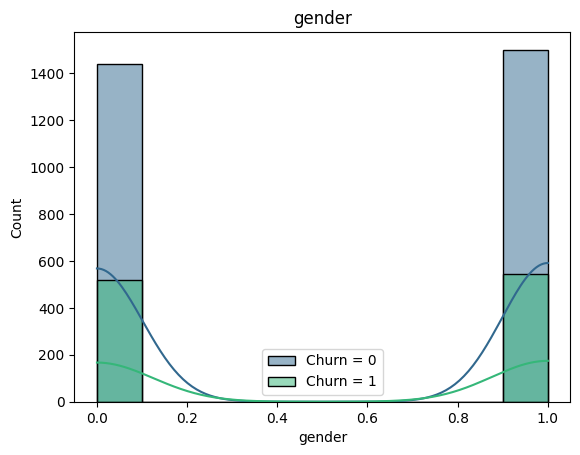

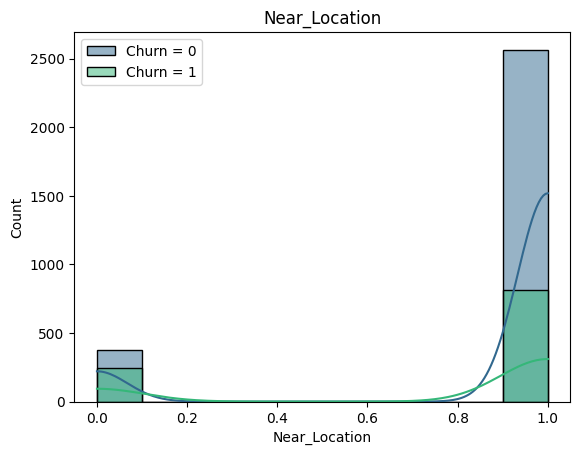

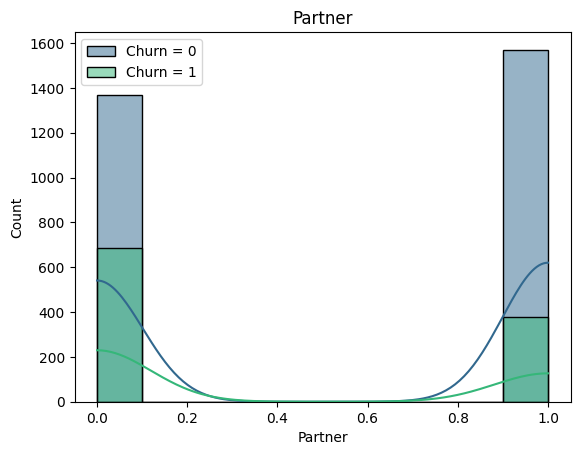

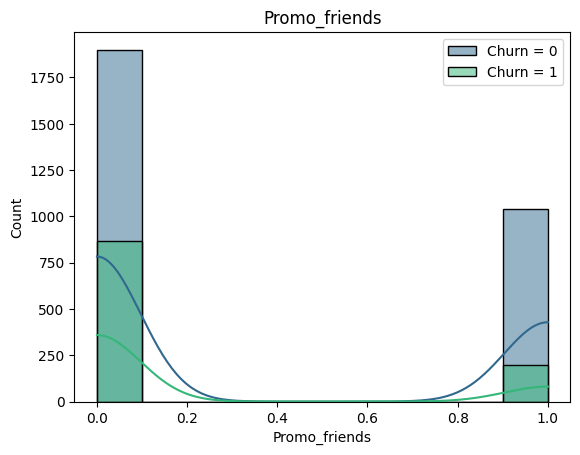

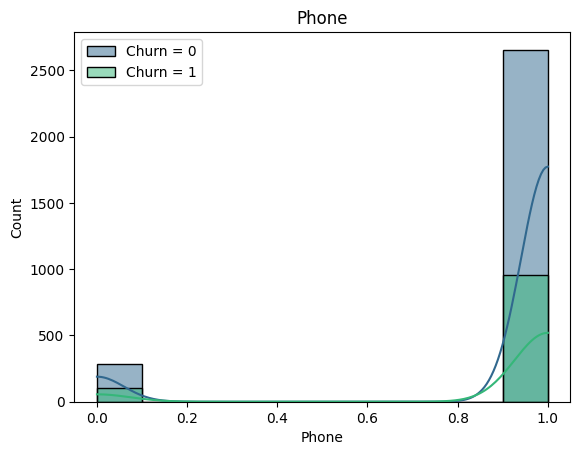

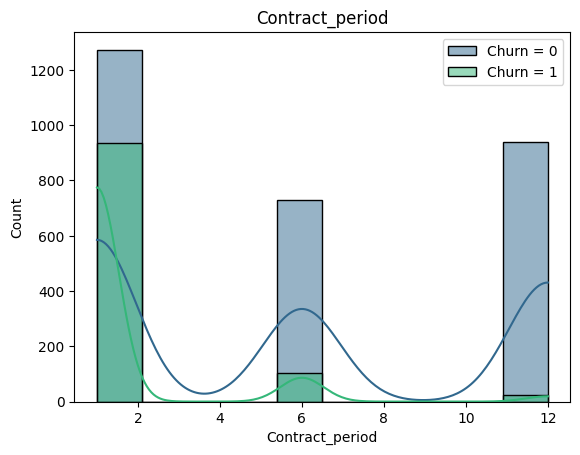

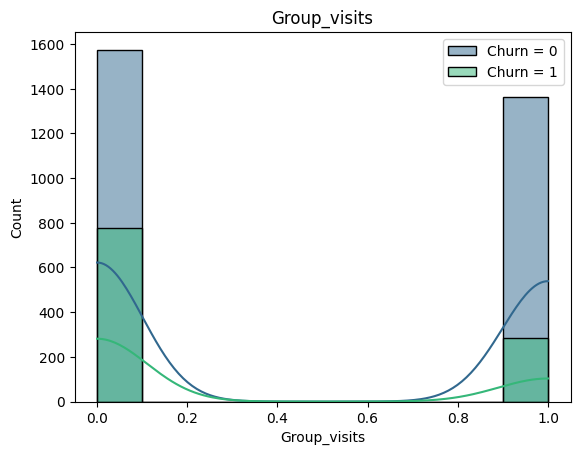

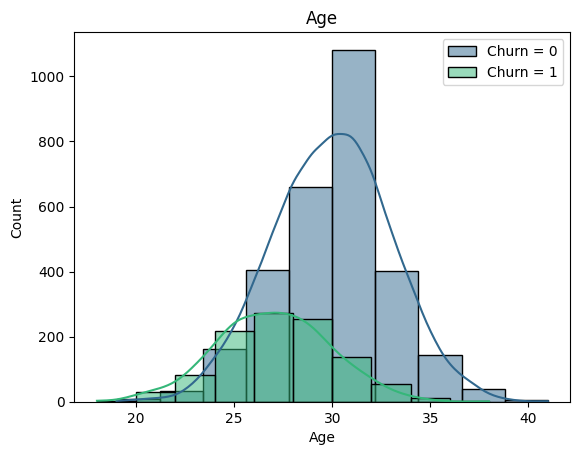

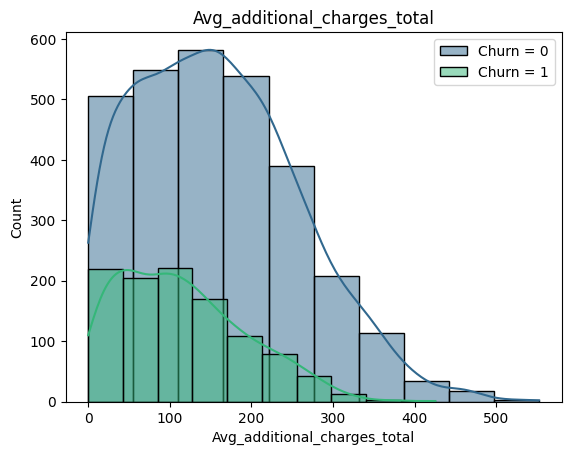

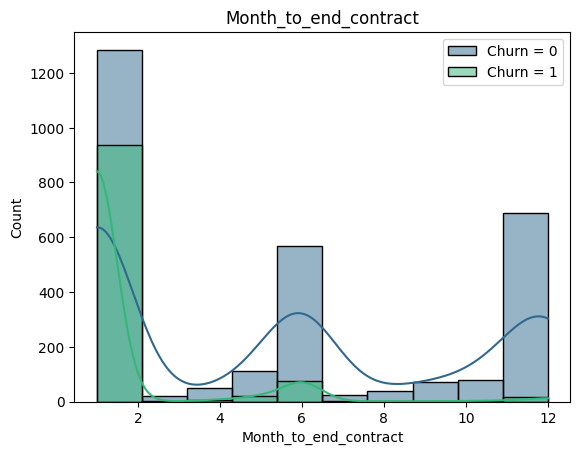

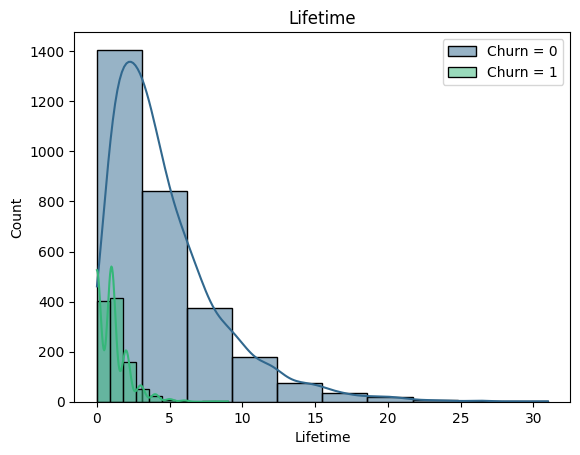

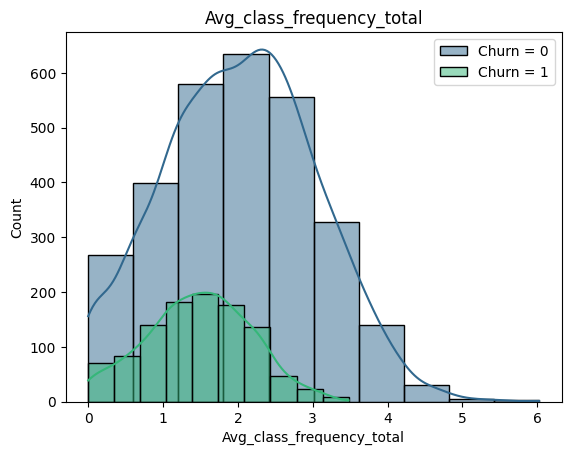

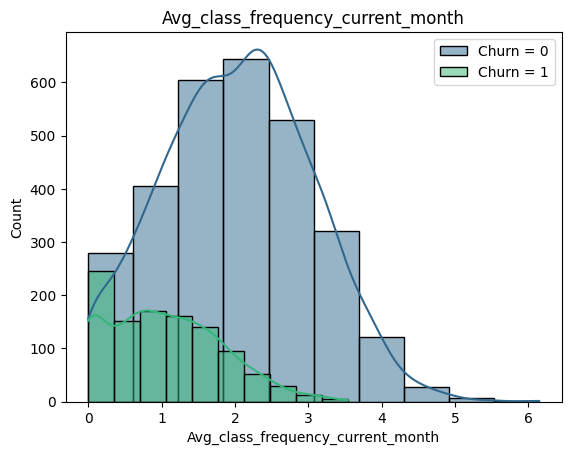

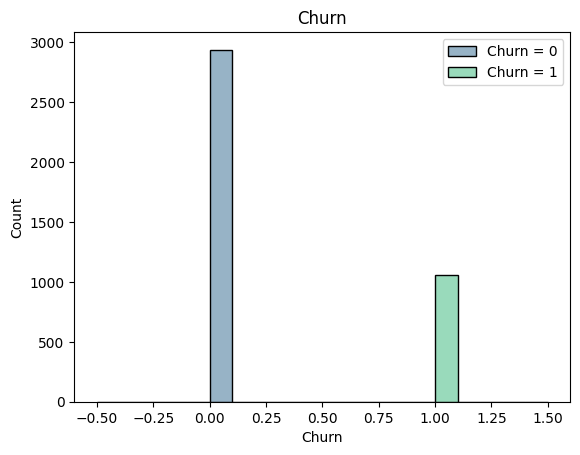

In [10]:
# Trazar gráficos
histogram(df, 'Churn', df.columns)

Crea una matriz de correlación y muéstrala.

In [11]:
df.corr()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
gender,1.000000,0.006699,-0.010463,-0.005033,-0.008542,0.000502,0.017879,0.013807,-0.009334,-0.001281,0.013579,0.014620,0.009156,0.000708
Near_Location,0.006699,1.000000,-0.005119,0.210964,-0.015763,0.150233,0.154728,0.058358,0.040761,0.143961,0.070921,0.043127,0.062664,-0.128098
Partner,-0.010463,-0.005119,1.000000,0.451960,0.009970,0.306166,0.022710,0.047480,0.022941,0.294632,0.061229,0.024938,0.045561,-0.157986
Promo_friends,-0.005033,0.210964,0.451960,1.000000,0.001982,0.244552,0.120170,0.050113,0.036898,0.239553,0.072721,0.028063,0.053768,-0.162233
Phone,-0.008542,-0.015763,0.009970,0.001982,1.000000,-0.006893,-0.010099,-0.011403,0.009279,-0.011196,-0.018801,0.008340,0.013375,-0.001177
Contract_period,0.000502,0.150233,0.306166,0.244552,-0.006893,1.000000,0.169991,0.138249,0.111445,0.973064,0.170725,0.096211,0.159407,-0.389984
Group_visits,0.017879,0.154728,0.022710,0.120170,-0.010099,0.169991,1.000000,0.080934,0.032079,0.163703,0.075853,0.056695,0.075923,-0.175325
Age,0.013807,0.058358,0.047480,0.050113,-0.011403,0.138249,0.080934,1.000000,0.080240,0.134511,0.164693,0.119953,0.183095,-0.404735
Avg_additional_charges_total,-0.009334,0.040761,0.022941,0.036898,0.009279,0.111445,0.032079,0.080240,1.000000,0.113958,0.079028,0.044426,0.079570,-0.198697
Month_to_end_contract,-0.001281,0.143961,0.294632,0.239553,-0.011196,0.973064,0.163703,0.134511,0.113958,1.000000,0.161078,0.085387,0.147605,-0.381393


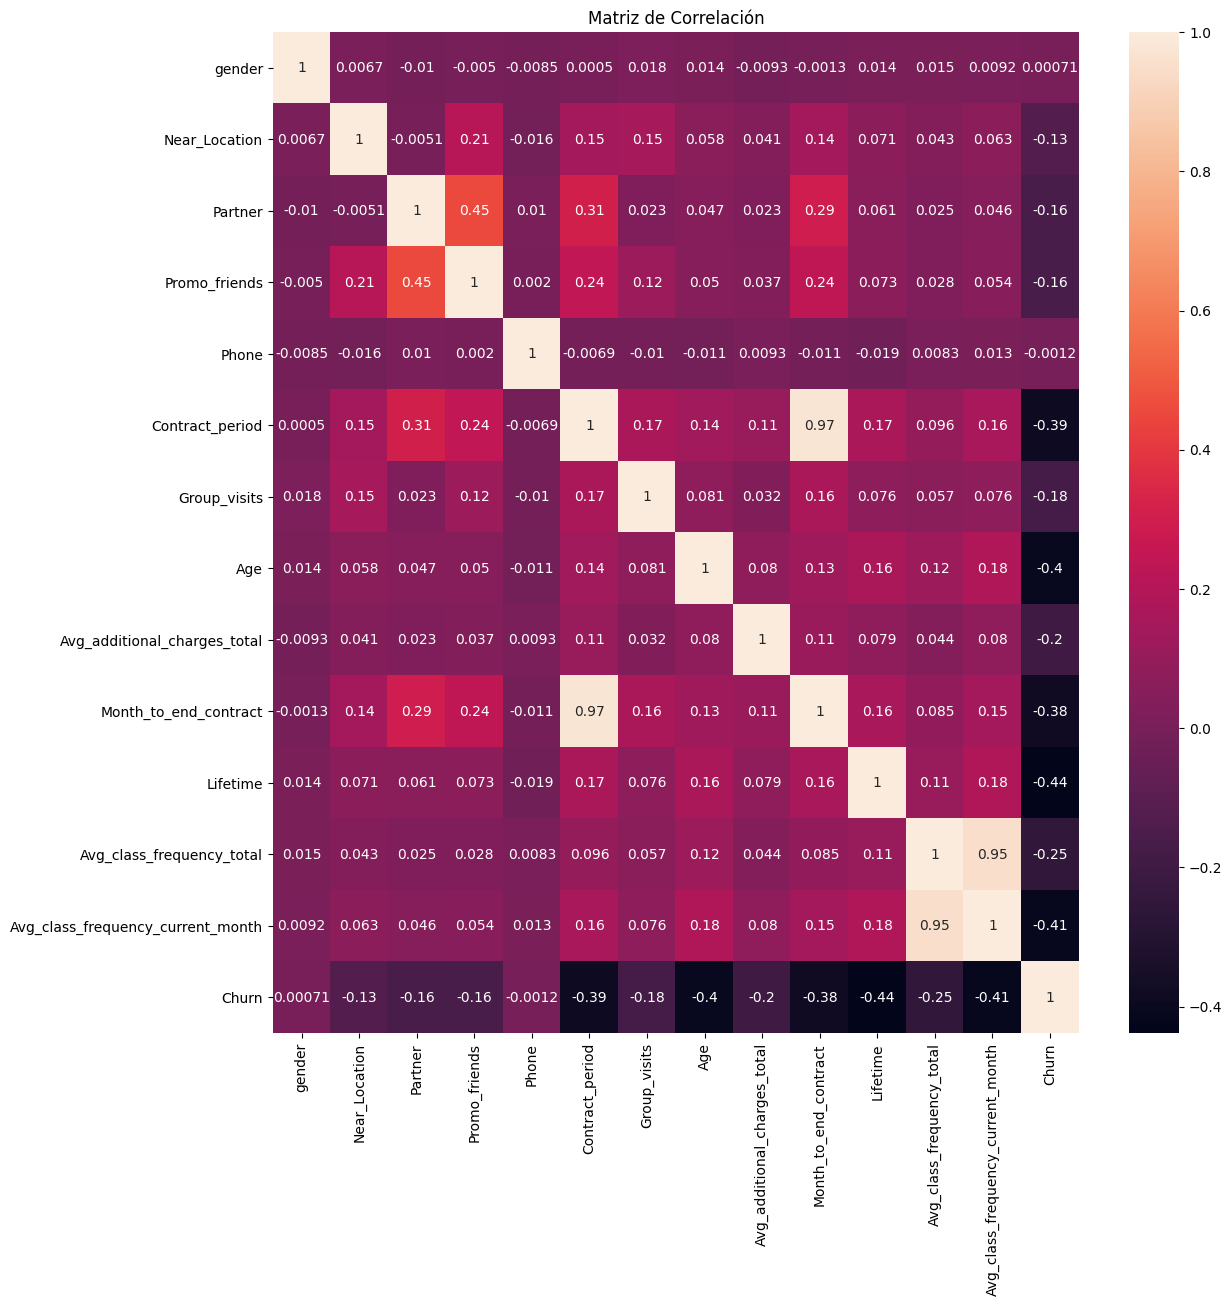

In [12]:
plt.figure(figsize=(13,13))
sns.heatmap(df.corr(), annot=True)
plt.title('Matriz de Correlación')
plt.show()

## Paso 3. Construir un modelo para predecir la cancelación de usuarios

Crea un modelo de clasificación binaria para clientes donde la característica objetivo es la marcha del usuario o la usuaria el mes siguiente.

In [13]:
# Dividir los datos

features = df.drop('Churn', axis=1)
target = df['Churn']

X_train, X_val, y_train, y_val = train_test_split(features, target, test_size=0.2)

print(X_train.shape)
print(X_val.shape)
print(y_train.shape)
print(y_val.shape)

(3200, 13)
(800, 13)
(3200,)
(800,)


In [14]:
# Entrenar Regresión Lógistica
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

LogisticRegression()

In [15]:
# Calcular Predicciones
y_proba_lr = lr_model.predict_proba(X_val)
y_pred_lr  = lr_model.predict(X_val)

In [16]:
# Evaluamos el modelo
print('Accuracy de la regresión :', accuracy_score(y_val, y_pred_lr))
print('Precision de la regresión:', precision_score(y_val, y_pred_lr))
print('Recall de la regresión   :', recall_score(y_val, y_pred_lr))

Accuracy de la regresión : 0.93125
Precision de la regresión: 0.8292682926829268
Recall de la regresión   : 0.8947368421052632


In [17]:
# Tarea: Desarrollar el Random Forest

## Paso. Crear clústeres de usuarios/as

Deja de lado la columna con datos sobre la cancelación e identifica los clústeres de objetos (usuarios/as):

### Estandariza los datos.    

In [20]:
sc = StandardScaler()
x_sc = sc.fit_transform(df.drop('Churn', axis=1))

In [21]:
linked = linkage(x_sc, method='ward')

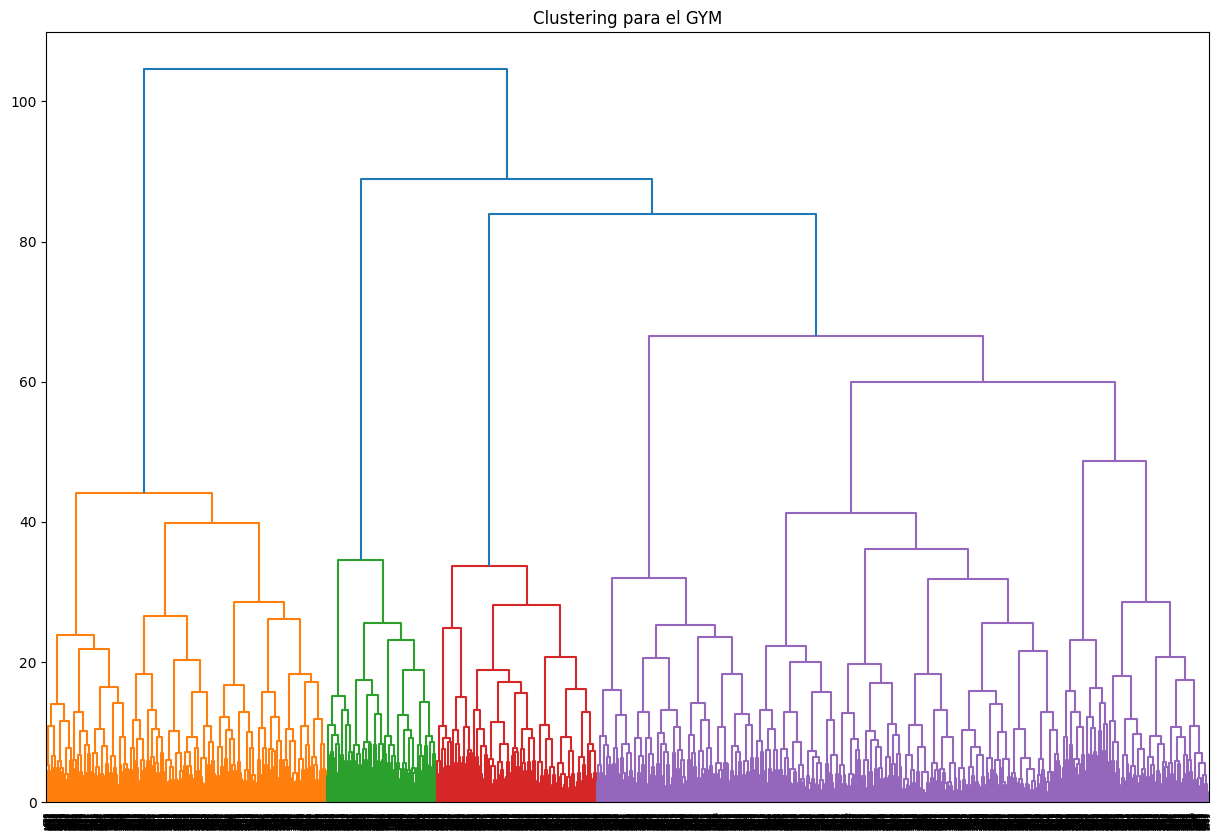

In [23]:
plt.figure(figsize=(15,10))
dendrogram(linked, orientation='top')
plt.title('Clustering para el GYM')
plt.show;

In [24]:
km = KMeans(n_clusters=5)
labels = km.fit_predict(df.drop('Churn', axis=1))

In [25]:
df['cluster_km'] = labels

In [27]:
df.groupby('cluster_km').mean()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
cluster_km,,,,,,,,,,,,,,
0,0.507737,0.824952,0.489362,0.293037,0.908124,4.203095,0.387814,28.902321,35.668921,3.858801,3.389749,1.837479,1.692402,0.350097
1,0.522727,0.880682,0.512784,0.346591,0.897727,5.406250,0.433239,29.335227,250.835362,5.008523,4.151989,1.903791,1.843484,0.178977
2,0.515093,0.839338,0.450828,0.280428,0.897760,4.296981,0.407011,28.980526,106.001106,3.993184,3.549172,1.851866,1.708535,0.333982
3,0.465201,0.857143,0.512821,0.333333,0.926740,5.805861,0.432234,29.864469,356.094365,5.362637,4.465201,2.017609,2.007574,0.043956
4,0.511435,0.844075,0.495842,0.320166,0.902287,4.755717,0.423077,29.401247,174.873445,4.376299,3.749480,1.895200,1.785569,0.226611


### Traza distribuciones

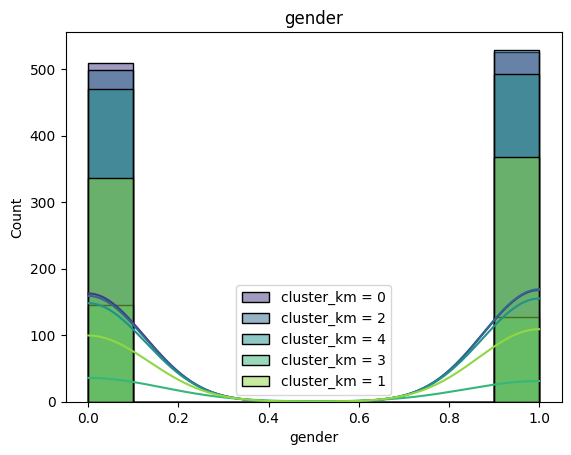

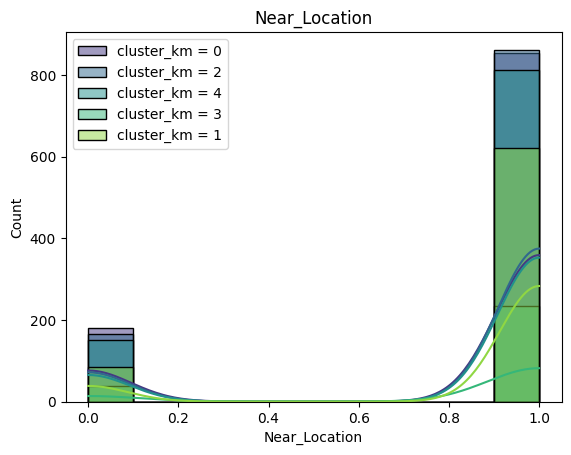

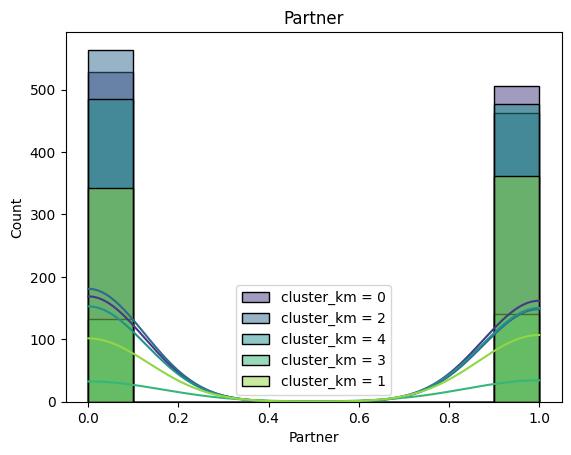

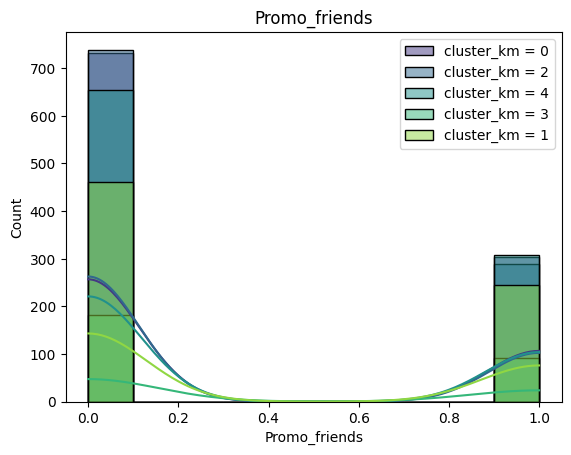

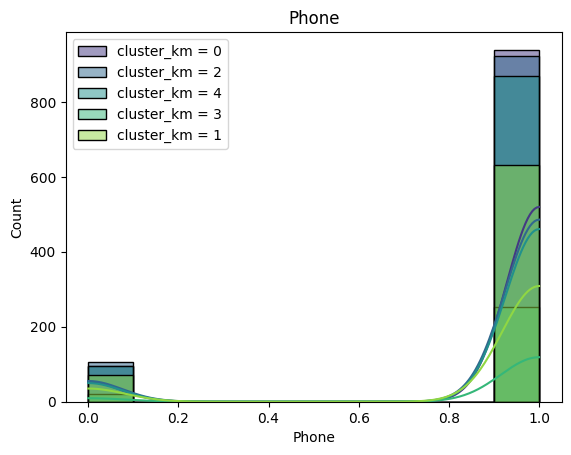

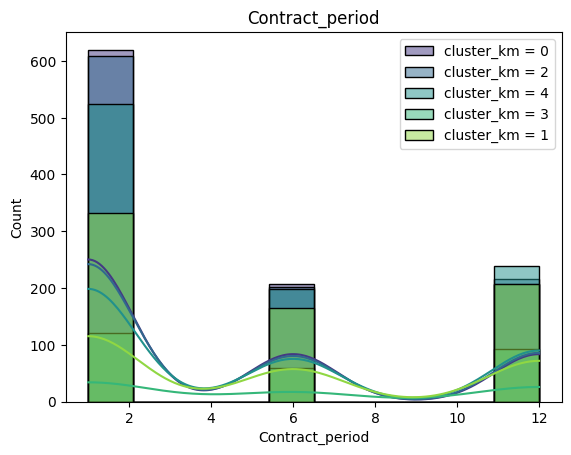

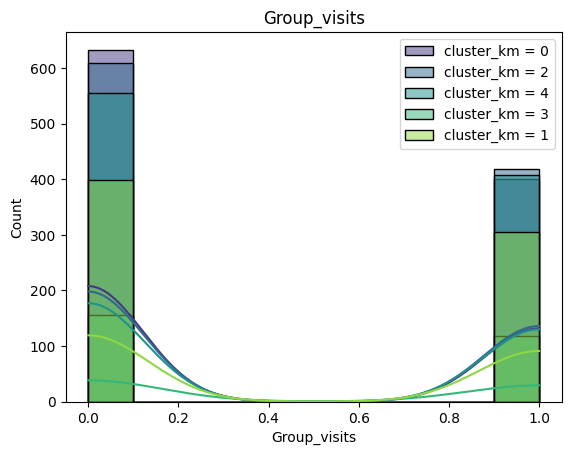

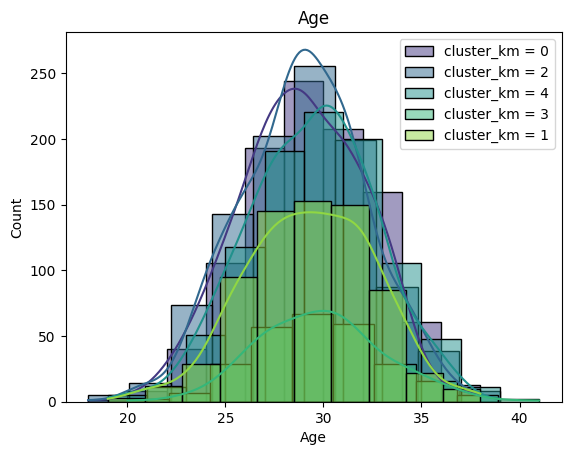

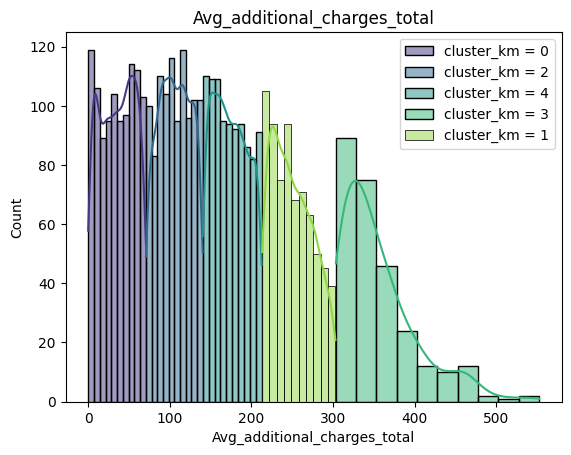

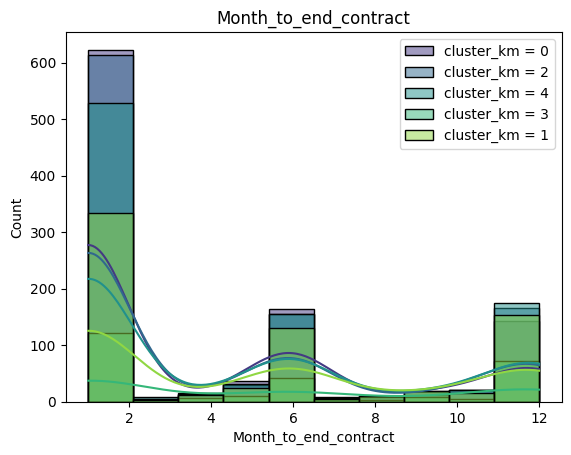

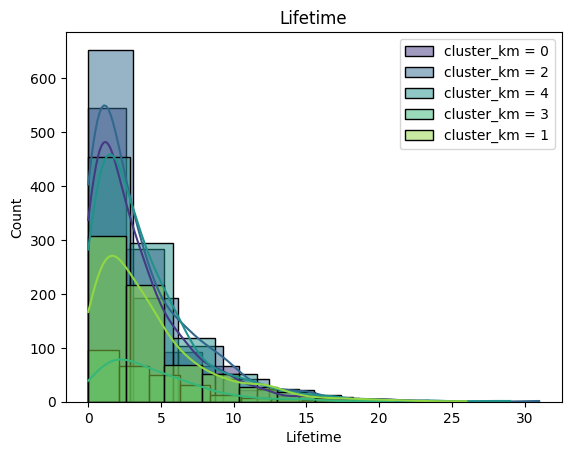

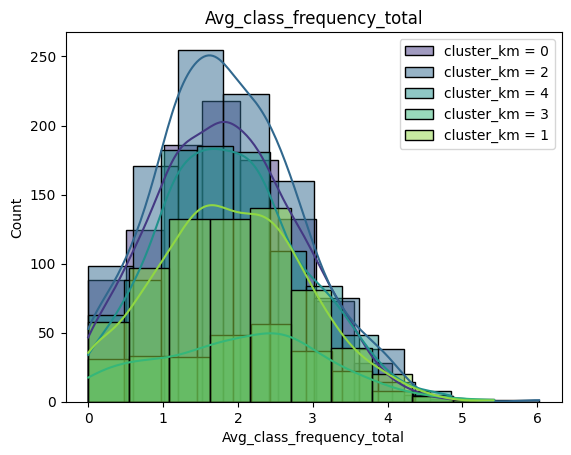

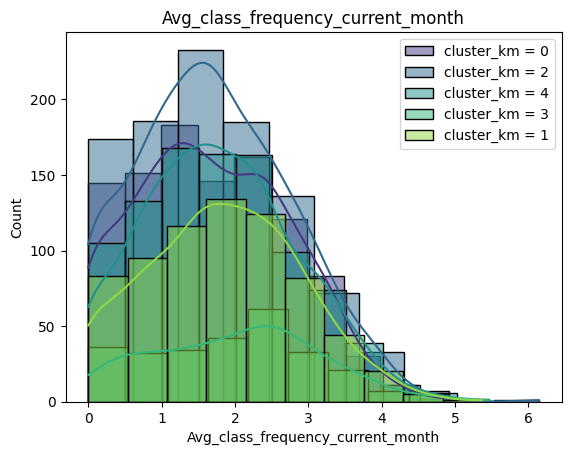

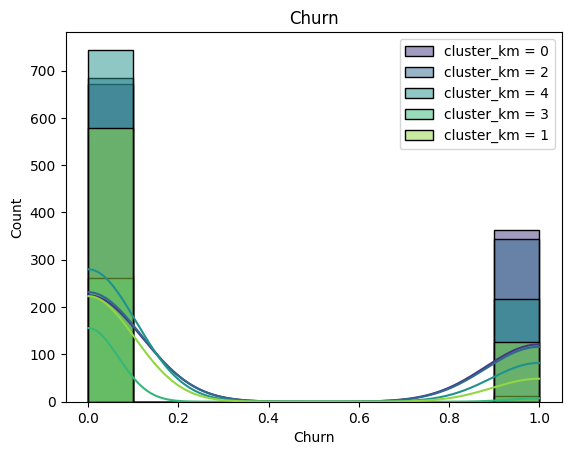

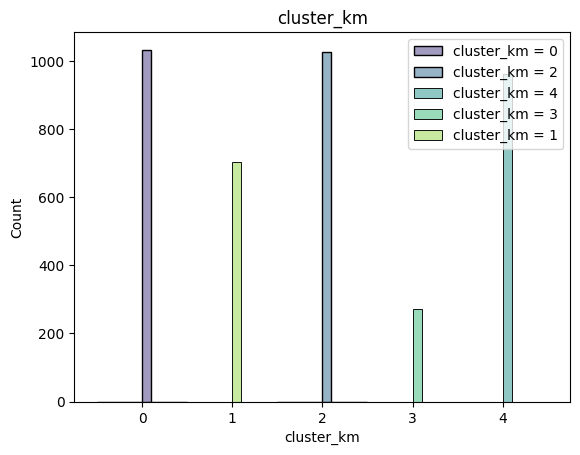

In [28]:
histogram(df, 'cluster_km', df.columns)

In [29]:
df.groupby('cluster_km')['Churn'].mean()

cluster_km
0    0.350097
1    0.178977
2    0.333982
3    0.043956
4    0.226611
Name: Churn, dtype: float64